## Object Detection in MS COCO

In [78]:
import os
import torch
import numpy as np
from torchvision import transforms
#--------------------------------------------
from skimage.filters import gaussian
from scipy.ndimage import gaussian_filter
import cv2

import matplotlib.pyplot as plt

import shap_bpt
print('shap_bpt version:',shap_bpt.__version__)

shap_bpt version: 1.0.2


In [79]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if ('mps' in dir(torch.backends)) and torch.backends.mps.is_available() else torch.device("cpu")
device

device(type='mps')

In [ ]:
import os
from pathlib import Path
import yaml

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / 'pyproject.toml').exists() and (path / 'shap_bpt').is_dir():
            return path
    raise FileNotFoundError('Could not find the project root from the current working directory.')

original_working_dir = Path.cwd()
project_root = find_project_root(original_working_dir)
os.chdir(project_root)
print(f'Project root: {project_root}')

try:
    with open(project_root / "examples/configs/MSCOCO_mac.yaml", "r") as f:
        config = yaml.safe_load(f)
finally:
    os.chdir(original_working_dir)
    print(f'Restored working directory: {original_working_dir}')

dataset_root = config["data"]["dataset_root"]


Project root: /Users/rashid/Nextcloud/RashidPHD/Codes/XAI/ShapBPT-SAM/shap_bpt_sam
Restored working directory: /Users/rashid/Nextcloud/RashidPHD/Codes/XAI/ShapBPT-SAM/shap_bpt_sam/examples/notebooks


In [81]:
from ultralytics import YOLO

model = YOLO(f'{original_working_dir}/checkpoints/yolo11s.pt')
class_names = model.names

print(f'{"Num_Classes":<15}{len(class_names)}')

model.info()

from pycocotools.coco import COCO

model_preprocess = transforms.Compose(
    [transforms.ToTensor()]
)

Num_Classes    80
YOLO11s summary: 181 layers, 9,458,752 parameters, 0 gradients, 21.7 GFLOPs


In [82]:
def load_image(fname,im_size=None,bg_type='black'):
    img_ = cv2.imread(f'{fname}')
    image_to_explain = cv2.cvtColor(img_, cv2.COLOR_BGR2RGB)                #.astype(np.float32)
    if im_size is not None:
        image_to_explain         = cv2.resize(image_to_explain,im_size)     # [:,:,::-1]
    image_to_explain_preproc  = image_to_explain.copy()                     #torch.tensor(image_to_explain).to(device)# .astype(np.float32)/255.0
    np.random.seed(0)
    bkgnd0 = np.full_like(image_to_explain, 0)
    bkgnd1 = np.full_like(image_to_explain, 127)
    bkgnd2 = np.full_like(image_to_explain, 255)
    bkgnd3 = gaussian(image_to_explain, 8, channel_axis=-1)*255
    bkgnd4 = np.clip(np.random.normal(128, 128, size=image_to_explain.shape), 0, 255).astype(np.uint8)
    bkgnd4 = (gaussian(bkgnd4, 2.0, channel_axis=-1) * 255).astype(np.uint8)
    if bg_type=='black': background_image_set = np.array([bkgnd0])
    elif bg_type=='gray': background_image_set = np.array([bkgnd1])
    elif bg_type=='white': background_image_set = np.array([bkgnd2])
    elif bg_type=='blurred': background_image_set = np.array([bkgnd3])
    elif bg_type=='noise': background_image_set = np.array([bkgnd4])
    elif bg_type=='full': background_image_set = np.array([bkgnd0, bkgnd1, bkgnd2, bkgnd3, bkgnd4])
    else: raise ValueError(f'Unknown bg_type: {bg_type}')
    background_image_preproc_set = [model_preprocess(bkgnd.astype(np.float32)/255.0)
                                        for bkgnd in background_image_set]
    background_tensors = torch.cat([torch.unsqueeze(bk_p, dim=0) 
                                    for bk_p in background_image_preproc_set]).to(device)
    return image_to_explain,image_to_explain_preproc,background_image_set,background_tensors

In [83]:
def predict_yolo(x,coco_classes_count=80,verbose=False):
    res = model.predict(source=x, verbose=verbose)[0]
    p = np.zeros(coco_classes_count)
    for cls,prob in zip(res.boxes.cls.cpu().numpy(), res.boxes.conf.cpu().numpy()):
        p[int(cls)] = prob
    return np.array(p)
#-----------------------------------------------------------------------
def predict_yolo_masked(masks,verbose=False):
    imglst_preds = []
    for mask in masks:
        preds = []
        for repl in background_image_set:
            # print(mask.shape, repl.shape)
            if len(mask.shape)!=3:
                mask3 = np.stack([mask,mask,mask], axis=2)
            else:
                print(mask.shape)
                mask3 = mask.copy()
            masked_image = np.where(mask3, image_to_explain, repl)
            preds.append(predict_yolo(masked_image,verbose=verbose))

        preds = np.mean(preds, axis=0)
        imglst_preds.append(preds)       
    
    return np.array(imglst_preds)

In [84]:
def load_image_to_explain(fname,bg_type='gray', load_gt=True):
    # global predicted_fS, predicted_f0, predicted_cls, sorted_classes, f_S, f_0,sorted_probs
    # global model_type,pretrained_model_type

    image_to_explain,image_to_explain_tensor,background_image_set,background_tensors = load_image(fname,bg_type=bg_type)
    h,w,_ = image_to_explain.shape
    # Foreground image to be explained  
    predicted_fS = predict_yolo(image_to_explain) 
    # predicted_fS = f(torch.unsqueeze(resnet50_preprocess(image_to_explain.astype(np.float32)/255.0).to(device), dim=0))[0]
    sorted_classes = np.flip(np.argsort(predicted_fS))
    sorted_probs   = predicted_fS[sorted_classes]
    predicted_cls = sorted_classes[0]
    f_S = float(predicted_fS[predicted_cls])
    #####################
    
    predicted_f0 = [predict_yolo(bkgnd.astype(np.float32)/255.0) for bkgnd in background_image_set]
    predicted_f0 = np.mean(predicted_f0,axis=0)
    f_0          = float(predicted_f0[predicted_cls])
    return image_to_explain,image_to_explain_tensor,background_image_set,background_tensors,predicted_fS,sorted_classes,sorted_probs,predicted_cls,f_S,predicted_f0,f_0
    # if load_gt:
        # image_no = int(image_path.split('\\')[-1].split('.')[0])

        # load_groundtruth(coco,image_path,fixed_category=fixed_category)
    

## SELECT IMAGE

In [85]:
## Get available precomputed SAM partitions
# fetch available unique image_ids from the partitions directory
image_ids = os.listdir("/Users/rashid/Nextcloud/RashidPHD/Codes/XAI/ShapBPT-SAM/shap_bpt_sam/examples/partitions")
image_ids = [f.split('.')[0].split('_')[0] for f in image_ids if '.npy' in f]
image_ids

['000000049091',
 '000000000632',
 '000000186929',
 '000000002299',
 '000000225757',
 '000000171382']

In [239]:
image_dir = config["data"]["image_dir"] # Update for your image directory
annotation_file =  config["data"]["annotation_file"] # Update for your annotation file
# image_id = '000000171382'  # Example image ID
image_id = '000000171382'  # Example image ID

image_path = os.path.join(image_dir, f'{image_id}.jpg')

In [240]:
coco = COCO(annotation_file)

loading annotations into memory...
Done (t=0.42s)
creating index...
index created!


In [241]:
image_to_explain,image_to_explain_tensor,background_image_set,background_tensors,\
    predicted_fS,sorted_classes,sorted_probs,predicted_cls,f_S,predicted_f0,f_0 = load_image_to_explain(image_path, bg_type='gray')
# fixed_category = 'tv'
fixed_category = class_names[predicted_cls]
print('fixed_category: ',fixed_category)

fixed_category:  skateboard


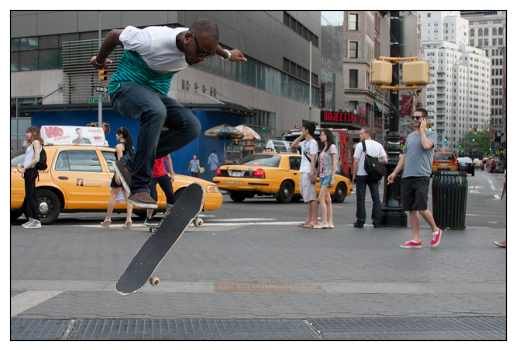

In [242]:
plt.imshow(image_to_explain)
plt.xticks([]); plt.yticks([]); 
# plt.title(f'Predicted Class: {fixed_category}'); plt.show()


In [243]:
# plt.imshow(background_image_set[0]); plt.xticks([]); plt.yticks([]); plt.show()

In [244]:
# image_no = 113235
image_no = int(image_id)

image_info = coco.loadImgs(image_no)[0]
ann_ids = coco.getAnnIds(imgIds=image_info['id'])
annotations = coco.loadAnns(ann_ids)
has_segmentation = any('segmentation' in ann for ann in annotations)
print(f"Segmentation annotations present: {has_segmentation}")

Segmentation annotations present: True


In [245]:
# image_info

In [246]:
categories = coco.loadCats(coco.getCatIds())
coco_categories = {cat['id']: cat['name'] for cat in categories}
# Get annotations for the selected image
ann_ids = coco.getAnnIds(imgIds=image_info['id'])
annotations = coco.loadAnns(ann_ids)

In [247]:
# Check if segmentation annotations are present
has_segmentation = any('segmentation' in ann for ann in annotations)
print(f"Segmentation annotations present: {has_segmentation}")
if has_segmentation:
    for ann in annotations:
        if 'segmentation' in ann:
            print(f"Segmentation Annotation: {ann['segmentation']}")
            break

Segmentation annotations present: True
Segmentation Annotation: [[268.16, 230.14, 281.43, 234.71, 285.17, 244.66, 288.48, 248.4, 294.71, 249.23, 301.76, 247.57, 305.08, 242.59, 312.54, 241.76, 317.11, 238.85, 323.74, 237.61, 330.8, 237.61, 339.92, 240.93, 337.85, 244.25, 344.9, 243.0, 345.32, 246.74, 349.88, 247.98, 356.1, 248.4, 359.42, 248.4, 363.98, 243.42, 366.89, 238.02, 374.77, 236.78, 371.86, 225.17, 374.35, 213.55, 373.52, 207.74, 374.35, 200.69, 376.84, 192.81, 377.26, 185.76, 341.17, 185.34, 315.45, 184.1, 306.32, 186.59, 299.27, 191.98, 289.31, 202.35, 275.62, 201.93, 268.99, 204.01, 267.33, 207.33, 267.33, 212.72, 262.35, 216.04, 262.35, 219.77, 264.01, 224.34, 268.99, 227.65, 270.65, 230.56], [412.93, 239.27, 416.25, 242.17, 418.33, 246.74, 424.13, 248.4, 427.04, 248.81, 432.84, 244.25, 435.33, 237.61, 441.14, 235.95, 441.97, 230.56, 439.48, 223.92, 432.43, 217.28, 420.81, 211.89, 418.74, 217.28, 419.15, 225.99, 413.76, 229.73, 412.1, 233.88, 413.76, 239.27], [394.27, 240.

In [248]:
def get_annotation(coco,image_no,category_name=None):
    if isinstance(image_no, str):
        image_no = int(image_no.split('\\')[-1].split('.')[0])
    
    image_info = coco.loadImgs(image_no)[0]
    if category_name is None:
        annotation_ids = coco.getAnnIds(imgIds=image_info['id'])
    else:
        category_ids = coco.getCatIds(catNms=[category_name])
        annotation_ids = coco.getAnnIds(imgIds=image_info['id'], catIds=category_ids)
    annotations = coco.loadAnns(annotation_ids)
    return annotations

def create_gt(coco,image_no,category_name=None, verbose=False):
    annotations = get_annotation(coco,image_no,category_name=category_name)
    if verbose:
        if len(annotations)>0:
            print(f"Image:{image_info['id']} has {len(annotations)} annotations")
    
    mask = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)
    category_mask = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)

    # Combine all masks for this image
    for ann in annotations:
        if 'segmentation' in ann:
            category_id = ann['category_id']  # Unique ID for object category
            # Decode the segmentation mask
            if isinstance(ann['segmentation'], list):  # Polygon format
                for seg in ann['segmentation']:
                    pts = np.array(seg).reshape(-1, 2).astype(np.int32)
                    cv2.fillPoly(mask, [pts], color=1)  # Fill the mask polygon
                    cv2.fillPoly(category_mask, [pts], color=category_id)
            elif isinstance(ann['segmentation'], dict):  # RLE format
                rle = ann['segmentation']
                decoded_mask = coco.annToMask(ann)
                mask += decoded_mask  # Add binary mask
                category_mask[decoded_mask > 0] = category_id  # Assign category ID
    
    # Resize masks to match actual image dimensions
    if mask.shape[:2] != image_to_explain.shape[:2]:
        # print(f"Resizing masks: Annotated={mask.shape}, Actual={image_to_explain.shape[:2]}")
        mask = cv2.resize(mask, (image_to_explain.shape[1], image_to_explain.shape[0]), interpolation=cv2.INTER_NEAREST)
        category_mask = cv2.resize(category_mask, (image_to_explain.shape[1], image_to_explain.shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask,category_mask,annotations

In [249]:
def load_groundtruth(coco,image_no,fixed_category=None):
    global ground_truth,weighted_ground_truth,annotations
    mask,ground_truth,annotations = create_gt(coco,image_no,category_name = fixed_category)
    weighted_ground_truth = gaussian_filter(ground_truth.astype(float), 16) * ground_truth
    ground_truth.dtype = 'bool'
fixed_category = fixed_category
load_groundtruth(coco,image_no,fixed_category=fixed_category)

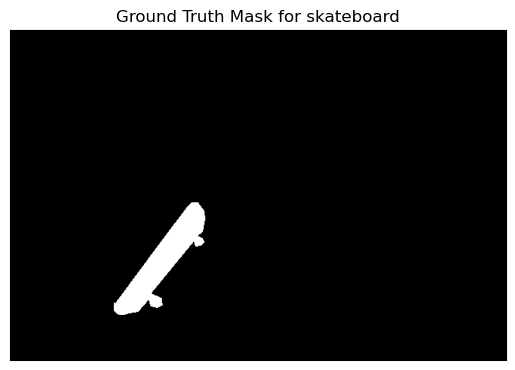

In [250]:
plt.imshow(ground_truth, cmap='gray'); plt.xticks([]); plt.yticks([]); plt.title(f'Ground Truth Mask for {fixed_category}'); plt.show()

In [251]:
# Perform inference on an image
def plot_predictions(image, results, category_name=None, filter_preds=True, line_thickness=2, exp_type='demo', save_fig=False, fig_size=(3, 3), title=None, selected_ext='png', destroy_fig=False):
    image_ = image.copy()
    plt.figure(figsize=fig_size)
    plt.imshow(image_); plt.axis('off')
    for result in results:
        # Access detected classes, confidences, and boxes
        class_ids = result.boxes.cls.cpu().numpy()  # Class IDs
        scores = result.boxes.conf.cpu().numpy()   # Confidence scores
        boxes = result.boxes.xyxy.cpu().numpy()    # Bounding boxes in xyxy format
        labels = model.names                       # Class labels (MS COCO classes)
        # Draw bounding boxes and labels on the image
        for box, class_id, score in zip(boxes, class_ids, scores):
            label = labels[int(class_id)]
            confidence = f"{score:.2f}"
            x1, y1, x2, y2 = map(int, box)  # Bounding box coordinates
            if filter_preds and category_name and label != category_name:
                continue
            width,height = x2 - x1, y2 - y1
            plt.gca().add_patch(plt.Rectangle((x1, y1), width, height, edgecolor='darkred', facecolor='none', linewidth=line_thickness))
            plt.text(x1, y1 - 5, f"{label} {confidence}", color='white', fontsize=12, bbox=dict(facecolor='darkred', alpha=0.5))
    plt.show()


In [252]:
results = model.predict(image_to_explain,verbose=True)


0: 448x640 16 persons, 5 cars, 2 traffic lights, 1 backpack, 1 skateboard, 63.9ms
Speed: 1.5ms preprocess, 63.9ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


In [253]:
# Extract top-k classes
def get_top_k_classes(results, k=5):
    # Predictions contain bounding boxes with associated scores and classes
    class_names = model.names
    top_k = []
    for result_ in results:
        boxes = result_.boxes  # List of bounding boxes
        for box in boxes:
            score,class_id = box.conf, box.cls  # Confidence score, # Class ID
            top_k.append((int(class_id.item()),class_names[int(class_id.item())], score.item()))
        # Sort by confidence and take top-k
        top_k = sorted(top_k, key=lambda x: x[2], reverse=True)[:k]
    return top_k

In [254]:
top_classes_n = 5

top_k_classes = get_top_k_classes(results, k=top_classes_n)
print("Top-k Classes (Class ID, Confidence):", top_k_classes)
print([class_names[int(cls)] for cls, _,_ in top_k_classes])
print('-'*120)
print('top_k_classes \t', top_k_classes)

Top-k Classes (Class ID, Confidence): [(36, 'skateboard', 0.951290488243103), (0, 'person', 0.926044225692749), (2, 'car', 0.8811174035072327), (0, 'person', 0.8720606565475464), (0, 'person', 0.8683409690856934)]
['skateboard', 'person', 'car', 'person', 'person']
------------------------------------------------------------------------------------------------------------------------
top_k_classes 	 [(36, 'skateboard', 0.951290488243103), (0, 'person', 0.926044225692749), (2, 'car', 0.8811174035072327), (0, 'person', 0.8720606565475464), (0, 'person', 0.8683409690856934)]


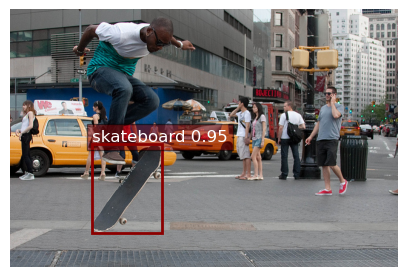

In [255]:
plot_predictions(image_to_explain,results,category_name = fixed_category,fig_size=(5,5), save_fig=False)

In [256]:
# MASKING FUNCTION
def predict_yolo_masked(masks):
    imglst_preds = []
    for mask in masks:
        preds = []
        for repl in background_image_set:
            if len(mask.shape)==2:
                mask3 = np.stack([mask,mask,mask], axis=2)
            else:
                mask3 = mask.copy()
            masked_image = np.where(mask3, image_to_explain, repl)
            preds.append(predict_yolo(masked_image))
        preds = np.mean(preds, axis=0)
        imglst_preds.append(preds)       
    return np.array(imglst_preds)

def predict_yolo(x,verbose=False):
    x = torch.from_numpy(x).to(device)
    x = x.cpu().numpy()
    res = model.predict(x,verbose=verbose)[0]
    p = np.zeros(80)
    for cls,prob in zip(res.boxes.cls.cpu().numpy(), res.boxes.conf.cpu().numpy()):
        p[int(cls)] = prob
    torch.cuda.empty_cache()
    return np.array(p)

In [257]:
print(image_to_explain.shape)
bg_ls = np.zeros((100,image_to_explain.shape[0],image_to_explain.shape[1],image_to_explain.shape[2]))
# bg_ls = np.random.randint(0, 255, (50,426, 640, 3), dtype=np.uint8)
print(bg_ls.shape)
pred = predict_yolo_masked(bg_ls)
print(pred.shape)
torch.cuda.empty_cache()

(426, 640, 3)
(100, 426, 640, 3)
(100, 80)


In [258]:
num_explained_classes        = 4
MAX_EVALS_BUDGET             = 100
explainer   = shap_bpt.Explainer(predict_yolo_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)

In [259]:
shap_values_bpt = explainer.explain_instance(MAX_EVALS_BUDGET, method='BPT',batch_size=16)
shap_values_aa = explainer.explain_instance(MAX_EVALS_BUDGET, method='AA',  batch_size=16)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

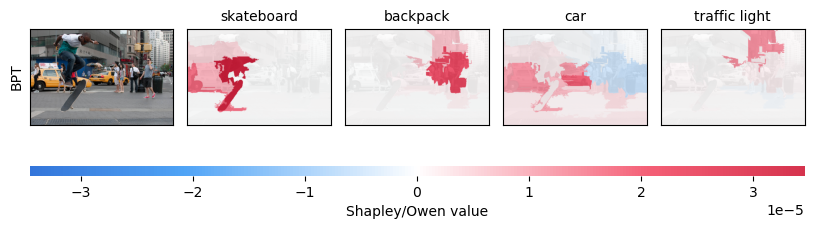

In [260]:
shap_bpt.plot_owen_values(explainer, [shap_values_bpt],class_names, names=['BPT'])

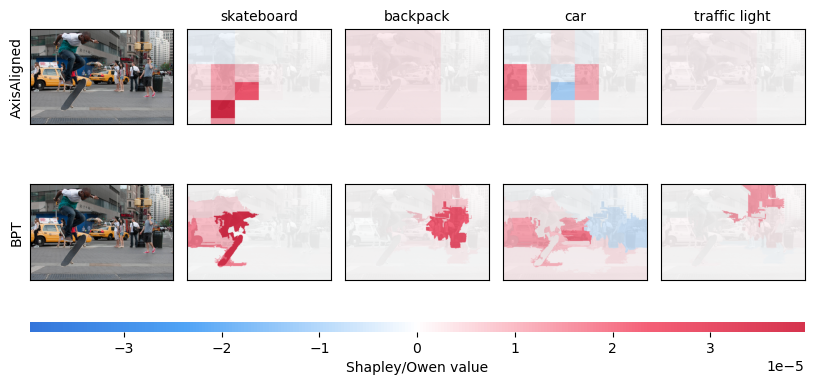

In [261]:
## PLOT OWEN VALUES
# shap_bpt.plot_owen_values(explainer, [shap_values_aa],class_names, names=['AxisAligned'])

shap_bpt.plot_owen_values(explainer, [shap_values_aa,shap_values_bpt],class_names, names=['AxisAligned','BPT'])

## Distance Functions

### ShapBPT with Custom BPT

In [262]:
# explainer   = shap_bpt.Explainer(predict_yolo_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)
# bptree = shap_bpt.build_bpt_from_image(image_to_explain, use_perim_term=True, use_area_term=True, use_color_term=True)
# print(bptree.N)
# # Compute Owen values with the BPT method
# shap_values_bpt = explainer.explain_instance(MAX_EVALS_BUDGET,bpt =bptree, method='BPT',batch_size=16)
# shap_bpt.plot_owen_values(explainer, shap_values_bpt, class_names)

In [263]:
# # Create the shap_bpt explainer using our masking-based black-box function
# MAX_EVALS_BUDGET = 100
# explainer   = shap_bpt.Explainer(predict_yolo_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)
# for use_perim_term in [True, False]:
#     for use_area_term in [True, False]:
#         for use_color_term in [True, False]:
#             bptree = shap_bpt.build_bpt_from_image(image_to_explain, use_perim_term=use_perim_term, use_area_term=use_area_term, use_color_term=use_color_term, 
#                                                 #    prebuilt_partitions=sam_partitions
#                                                 )
#             # Compute Owen values with the BPT method
#             shap_values_bpt = explainer.explain_instance(MAX_EVALS_BUDGET,bpt =bptree, method='BPT',batch_size=16)

#             active_terms = []
#             if use_perim_term: active_terms.append('Perimeter')
#             if use_area_term: active_terms.append('Area')
#             if use_color_term: active_terms.append('Color')
#             string_names = ' | '.join(active_terms) or 'No terms'

#             shap_bpt.plot_owen_values(explainer, shap_values_bpt, class_names, names=[string_names])

In [264]:
print('Expected Shapley explanation: ', explainer.base_f_S[0] - explainer.base_f_0[0])
print('Computed Shapley explanation: ', np.sum(shap_values_bpt[0]))

Expected Shapley explanation:  0.951290488243103
Computed Shapley explanation:  0.9512904882431032


## Genearte/LOAD SAM

(426, 640, 3)


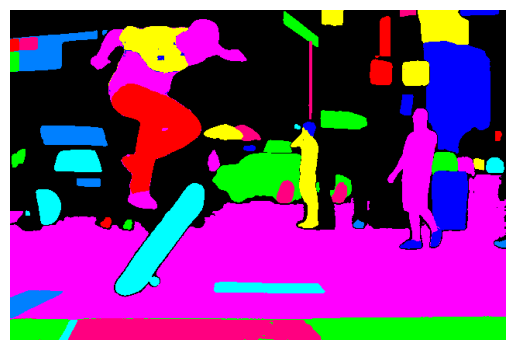

In [265]:
partition = cv2.imread(f'../partitions/{image_id}_sam.png',
                    #    cv2.IMREAD_GRAYSCALE
                       )
print(partition.shape)  # (H, W)
plt.imshow(partition, cmap="gray")
plt.axis("off")
plt.show()

## Refined Masks

(426, 640)
66


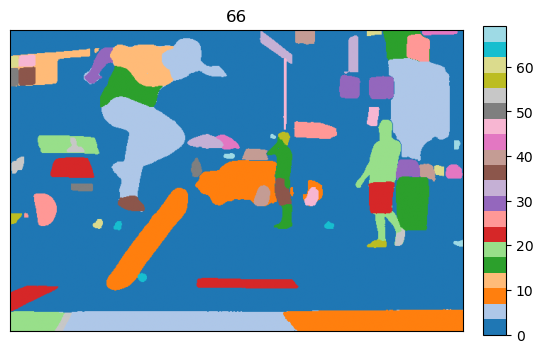

In [266]:
masks = np.load(f"../partitions/{image_id}_refined.npy").astype(np.uint16)

print(masks.shape)  # (H, W)
print(len(np.unique(masks)))
im = plt.imshow(masks, cmap="tab20")
plt.colorbar(im, fraction=0.046, pad=0.04, aspect=13.5)
plt.title(f'{len(np.unique(masks))}');
plt.xticks([]); plt.yticks([]);
plt.show()

## WITH SAM

In [267]:
partitions = masks

print(partitions.shape)
print(partitions.dtype)
print(partitions.min(), partitions.max())
print(np.unique(partitions).size)
print(np.unique(partitions)[:20])

(426, 640)
uint16
0 69
66
[ 0  1  4  5  6  7  8 10 12 13 14 15 16 17 18 19 20 21 22 23]


### ONLY SAM

In [268]:
from scipy import ndimage as ndi
import numpy as np

def cap_partition_labels(partitions, max_labels=64):
    partitions = np.asarray(partitions).astype(np.int64)

    labels, counts = np.unique(partitions, return_counts=True)

    if len(labels) <= max_labels:
        keep_labels = labels
    else:
        # Keep the largest regions, merge tiny extras into nearest kept region
        keep_labels = labels[np.argsort(counts)[-max_labels:]]

    keep_mask = np.isin(partitions, keep_labels)

    if not np.all(keep_mask):
        # For every removed pixel, copy nearest kept label
        _, nearest_idx = ndi.distance_transform_edt(~keep_mask, return_indices=True)
        partitions = partitions.copy()
        partitions[~keep_mask] = partitions[tuple(idx[~keep_mask] for idx in nearest_idx)]

    # Remap labels to contiguous 0..K-1
    unique_ids = np.unique(partitions)
    remap = {old: new for new, old in enumerate(unique_ids)}
    partitions = np.vectorize(remap.get)(partitions).astype(np.uint8)

    return partitions

In [269]:
path_results = os.path.join(original_working_dir, 'results')
path_results_img = os.path.join(path_results, str(image_no))
os.makedirs(path_results, exist_ok=True)
os.makedirs(path_results_img, exist_ok=True)


In [270]:

from matplotlib.colors import LinearSegmentedColormap

# Custom colormap for Shapley values - similar to 'seismic' but with lighter tones.
shapley_values_colormap = LinearSegmentedColormap.from_list("shapley_values_colormap", 
                                                            [(0.0, '#0053d1'),
                                                             (0.2, '#248df4'),
                                                             (0.5, 'white'),  
                                                             (0.8, '#f23754'),
                                                             (1.0, '#cb0021')])


def plot_owen_values(explainer, shap_values, class_names, figure_name, save_plot=True,savepath=None, names=None):
    """
    Visualize ShapBPT explanations.

    Parameters
    ----------
    explainer : Explainer
        Fitted explanation object.

    shap_values : np.ndarray
        Explanation maps.

    class_names : list[str]
        Names of model output classes.

    names : list[str], optional
        Row labels for multiple explanation sets.

    Returns
    -------
    None
        Displays a matplotlib figure.
    """
    shap_values = np.array(shap_values)
    if len(shap_values.shape)==3: shap_values = np.array([shap_values])
    max_val = np.nanpercentile(np.abs(shap_values.flatten()), 99.9)
    num_explained_classes = len(explainer.base_f_S)
    num_rows = len(shap_values)
    fig,axes = plt.subplots(num_rows+1, num_explained_classes+1, 
                            figsize=(2*(num_explained_classes+1), 2*(num_rows+0.3)), 
                            squeeze=False,
                            height_ratios=[1]*num_rows + [0.3])
    base_image = explainer.image_to_explain
    if np.max(base_image)>1: base_image = base_image.astype(np.uint8)
    if len(base_image.shape)==2:
        base_image = np.stack([base_image, base_image, base_image], axis=-1)
    img_grey = (0.2989 * base_image[:, :, 0] +
                0.5870 * base_image[:, :, 1] + 
                0.1140 * base_image[:, :, 2])
    # axes[0].set_title(f'real: {class_names[expected_class]}')
    for r in range(num_rows):
        axes[r,0].imshow(base_image)
        for i in range(num_explained_classes):
            axes[r,i+1].imshow(img_grey.astype(base_image.dtype), alpha=0.50, cmap='gray')
            im=axes[r,i+1].imshow(shap_values[r,i], cmap=shapley_values_colormap, vmin = -max_val, vmax = max_val, alpha=0.80)
            if r==0: axes[r,i+1].set_title(f'{class_names[explainer.output_indexes[i]]}', fontsize=10)#+
                                #f'\n{explainer.base_f_S[i]:.5} to {explainer.base_f_0[i]:.5}')
        for jjj in range(num_explained_classes+1): axes[r,jjj].set_xticks([]) ; axes[r,jjj].set_yticks([])
    if names is not None:
        for r in range(num_rows):
            axes[r,0].set_ylabel(names[r])
    # Use the last row for the colorbar
    for ax in axes[-1,:]:
        ax.set_axis_off()
        # ax.set_box_aspect(0.1)
    cb = fig.colorbar(im, ax=axes[-1,:], label="Shapley/Owen value", 
                      orientation="horizontal", aspect=80, fraction=0.9)#, location='bottom') #,  fraction=0.5, 
    cb.outline.set_visible(False)
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    if save_plot: plt.savefig(os.path.join(savepath, figure_name), dpi=300, bbox_inches='tight')
    # plt.tight_layout()
    plt.show()


def plot_single_attributions(shap_values, savepath, figure_name, save_plot=True, factor=1,
                             destroy_fig=True, robust_percentile=99.5):
    exp_code, _ = figure_name.split('_')[:2]

    shap_values = np.array(shap_values)
    shap_values_1 = shap_values[0] if shap_values.ndim == 3 else shap_values
    if shap_values_1.ndim != 2:
        raise ValueError(f'Expected a 2D attribution map or a 3D class stack, got {shap_values.shape}')

    finite_abs = np.abs(shap_values_1[np.isfinite(shap_values_1)])
    nonzero_abs = finite_abs[finite_abs > 0]
    if nonzero_abs.size == 0:
        max_val = 1.0
    else:
        max_val = np.nanpercentile(nonzero_abs, robust_percentile)
        if not np.isfinite(max_val) or max_val <= 0:
            max_val = np.nanmax(nonzero_abs)
        max_val = max_val + factor * 1e-12

    print(f'{figure_name}: color scale [-{max_val:.4g}, {max_val:.4g}]')
    fig = plt.figure(figsize=(6, 6))
    ax = plt.imshow(shap_values_1, cmap=shapley_values_colormap, vmin = -max_val, vmax = max_val)
    plt.colorbar(ax, fraction=0.03)#, location='bottom') #,  fraction=0.5, 
    plt.xticks([]); plt.yticks([]);
    # plt.tight_layout()
    if save_plot: plt.savefig(os.path.join(savepath, figure_name), dpi=300, bbox_inches='tight')
    if destroy_fig: plt.close(fig)  
    plt.show()

# plot_single_attributions(shap_values_bpt_sam, path_results,  figure_name)

## CREATE A MAPPING TABLE for this


In [271]:
import pandas as pd

experiment_map = {
    "E1": {"use_area_term": True,  "use_perim_term": True,  "use_color_term": True},
    "E2": {"use_area_term": True,  "use_perim_term": True,  "use_color_term": False},
    "E3": {"use_area_term": True,  "use_perim_term": False, "use_color_term": True},
    "E4": {"use_area_term": True,  "use_perim_term": False, "use_color_term": False},
    "E5": {"use_area_term": False, "use_perim_term": True,  "use_color_term": True},
    "E6": {"use_area_term": False, "use_perim_term": True,  "use_color_term": False},
    "E7": {"use_area_term": False, "use_perim_term": False, "use_color_term": True},
    "E8": {"use_area_term": False, "use_perim_term": False, "use_color_term": False},
}

# Direct lookup table (E1 -> flags)
experiment_table = pd.DataFrame.from_dict(experiment_map, orient="index")
experiment_table.index.name = "Exp"
experiment_table = experiment_table.reset_index()
experiment_table["description"] = experiment_table.apply(
    lambda row: "+".join(
        part for part, enabled in [
            ("area", row["use_area_term"]),
            ("perimeter", row["use_perim_term"]),
            ("color", row["use_color_term"]),
        ]
        if enabled
    ) or "none",
    axis=1,
)

# Inverse lookup table (flags -> E1)
experiment_inverse_map = {
    (cfg["use_area_term"], cfg["use_perim_term"], cfg["use_color_term"]): exp
    for exp, cfg in experiment_map.items()
}

print(experiment_table)

# Save this table if needed:
# experiment_table.to_csv("experiment_mapping_table.csv", index=False)
# with open("experiment_mapping_table.json", "w") as f:
#     experiment_table.to_json(f, orient="records", indent=2)


def get_experiment_config(code: str):
    """Return the configuration dictionary for an experiment code like E1."""
    return experiment_map[code]


def get_experiment_code(use_area_term: bool, use_perim_term: bool, use_color_term: bool):
    """Return the experiment code like E1 for a given flag combination."""
    key = (use_area_term, use_perim_term, use_color_term)
    return experiment_inverse_map[key]


def explain_experiment(code: str):
    """Return a readable description of an experiment code like E1."""
    cfg = get_experiment_config(code)
    active = [name.replace("use_", "").replace("_term", "") for name, enabled in cfg.items() if enabled]
    return f"{code}: {' + '.join(active) if active else 'none'}"


def explain_flags(use_area_term: bool, use_perim_term: bool, use_color_term: bool):
    """Return a readable description for a given flag combination."""
    code = get_experiment_code(use_area_term, use_perim_term, use_color_term)
    return explain_experiment(code)

# Examples:
# print(get_experiment_code(True, True, True))   # E1
# print(get_experiment_config("E1"))
# print(explain_experiment("E1"))
# print(explain_flags(True, True, True))

  Exp  use_area_term  use_perim_term  use_color_term           description
0  E1           True            True            True  area+perimeter+color
1  E2           True            True           False        area+perimeter
2  E3           True           False            True            area+color
3  E4           True           False           False                  area
4  E5          False            True            True       perimeter+color
5  E6          False            True           False             perimeter
6  E7          False           False            True                 color
7  E8          False           False           False                  none


In [272]:
print(get_experiment_code(True, True, True))   # E1
print(get_experiment_config("E1"))
print(explain_experiment("E1"))
print(explain_flags(True, True, True))

E1
{'use_area_term': True, 'use_perim_term': True, 'use_color_term': True}
E1: area + perim + color
E1: area + perim + color


In [273]:
MAX_EVALS_BUDGET = 100

### ONLY SAM

545279


  0%|          | 0/100 [00:00<?, ?it/s]

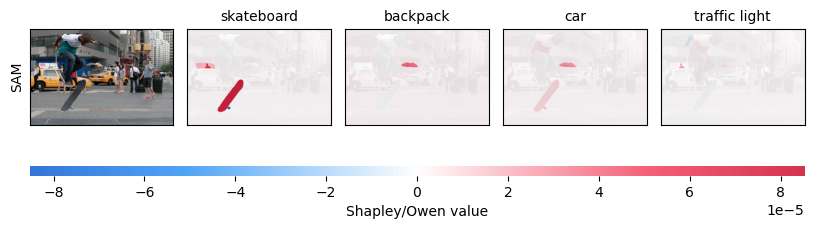

In [274]:
explainer   = shap_bpt.Explainer(predict_yolo_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)
partitions = cap_partition_labels(masks, max_labels=63)
bptree = shap_bpt.build_bpt_from_image(
                        image_to_explain,
                        use_perim_term=False,
                        use_area_term=False,
                        use_color_term=False,
                        prebuilt_partitions=partitions,
)
print(bptree.N)
# Compute Owen values with the BPT method
shap_values_sam = explainer.explain_instance(MAX_EVALS_BUDGET,bpt =bptree, method='BPT',batch_size=16)
shap_bpt.plot_owen_values(explainer, shap_values_sam, class_names, names=['SAM'])

## Color + Area + Perimeter + SAM

545279


  0%|          | 0/100 [00:00<?, ?it/s]

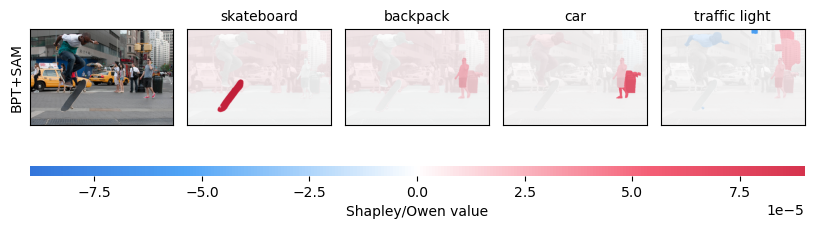

In [275]:
explainer   = shap_bpt.Explainer(predict_yolo_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)
partitions = cap_partition_labels(masks, max_labels=63)
bptree = shap_bpt.build_bpt_from_image(image_to_explain,
                                        use_perim_term=True,
                                          use_area_term=True,
                                            use_color_term=True,
                                            prebuilt_partitions=partitions
                                            )
print(bptree.N)
# Compute Owen values with the BPT method
shap_values_bpt_sam = explainer.explain_instance(MAX_EVALS_BUDGET,bpt =bptree, method='BPT',batch_size=16)
shap_bpt.plot_owen_values(explainer, shap_values_bpt_sam, class_names, names=['BPT+SAM'])

AA 3.964640368087537e-05
AA_171382: color scale [-3.965e-05, 3.965e-05]


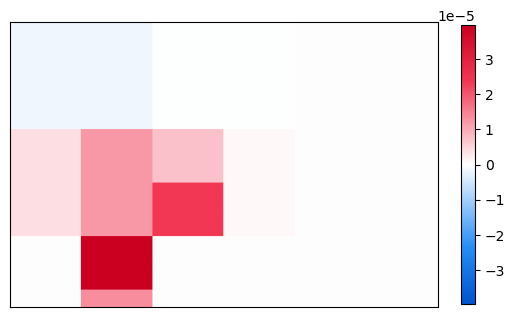

BPT 3.456952028724505e-05
BPT_171382: color scale [-3.457e-05, 3.457e-05]


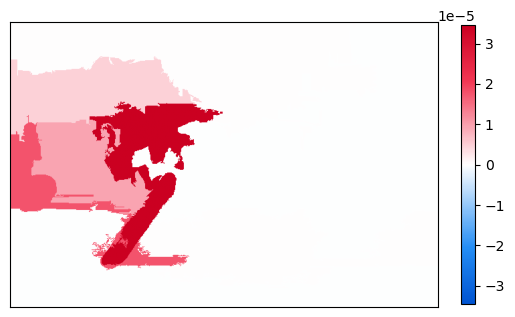

SAM 0.0012618928155246972
SAM_171382: color scale [-0.0001738, 0.0001738]


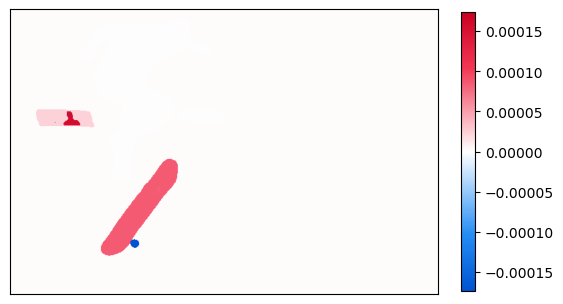

BPT-SAM 9.005553675398359e-05
BPT-SAM_171382: color scale [-9.006e-05, 9.006e-05]


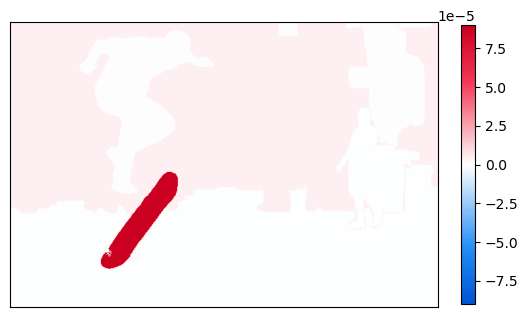

In [276]:
shap_values_all_4 = []

for exp_code, shap_values in zip(['AA','BPT','SAM','BPT-SAM'],[shap_values_aa, shap_values_bpt, shap_values_sam, shap_values_bpt_sam]):
    data = {
        'exp_code': exp_code,
        'shap_values': shap_values[0]
    }
    shap_values_all_4.append(data)
    print(exp_code, np.max(np.abs(shap_values)))
    plot_single_attributions(shap_values, path_results_img,  f'{exp_code}_{image_no}',robust_percentile=99.9985, destroy_fig=False)

## ALL Distance Functions

  0%|          | 0/100 [00:00<?, ?it/s]

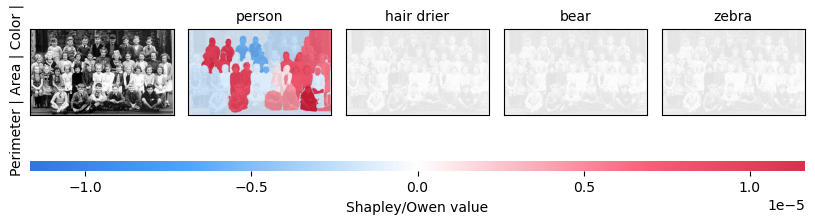

E1_SAM_2299.png: color scale [-1.166e-05, 1.166e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

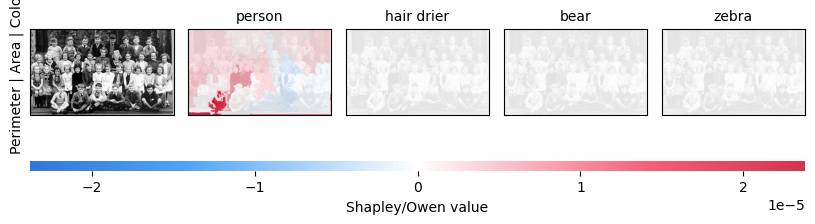

E1_noSAM_2299.png: color scale [-2.378e-05, 2.378e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

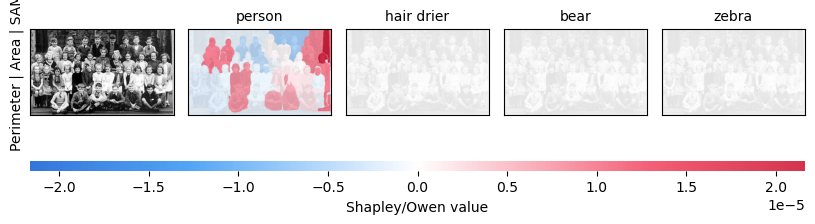

E2_SAM_2299.png: color scale [-2.162e-05, 2.162e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

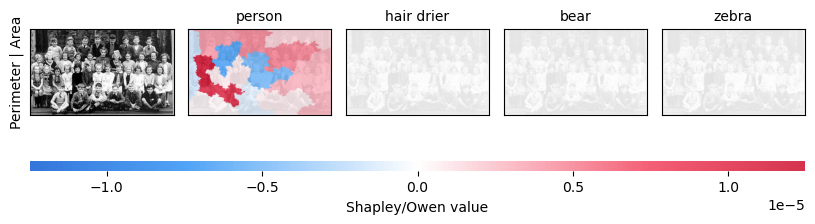

E2_noSAM_2299.png: color scale [-1.247e-05, 1.247e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

Reached 6 terminals.


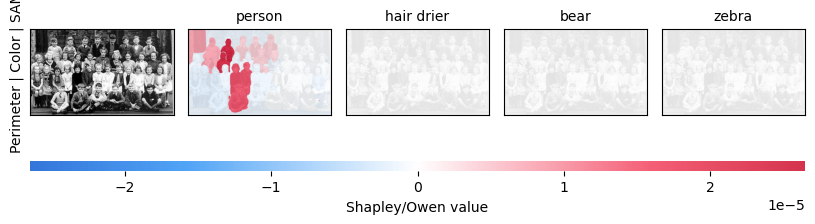

E5_SAM_2299.png: color scale [-2.647e-05, 2.647e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

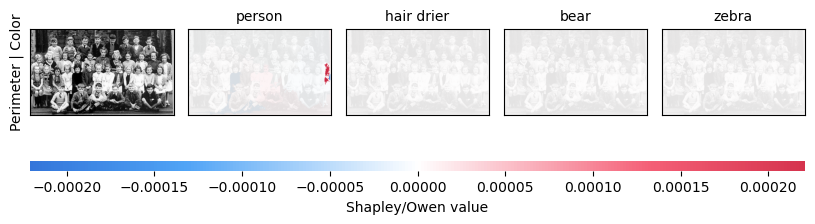

E5_noSAM_2299.png: color scale [-9.431e-06, 9.431e-06]


  0%|          | 0/100 [00:00<?, ?it/s]

Reached 6 terminals.


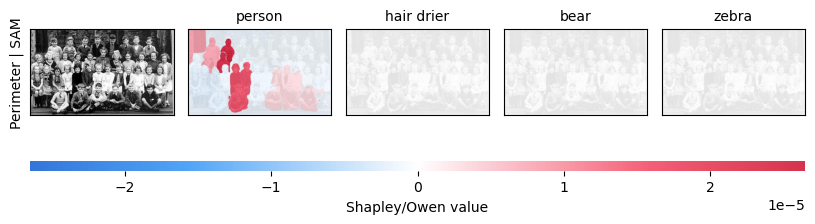

E6_SAM_2299.png: color scale [-2.647e-05, 2.647e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

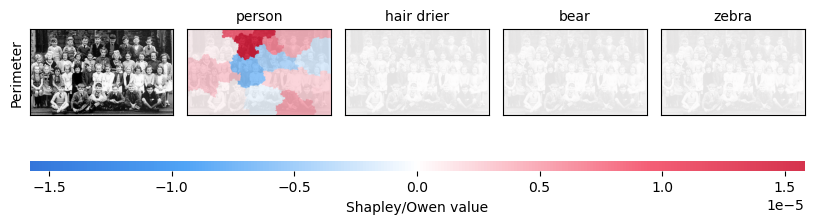

E6_noSAM_2299.png: color scale [-1.58e-05, 1.58e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

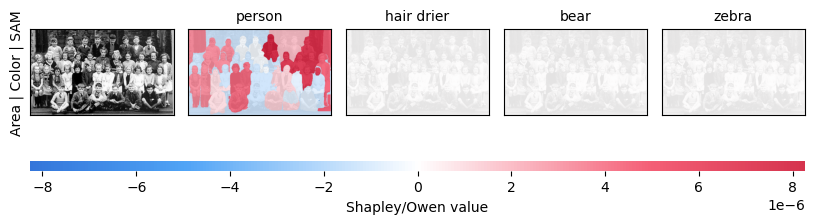

E3_SAM_2299.png: color scale [-8.265e-06, 8.265e-06]


  0%|          | 0/100 [00:00<?, ?it/s]

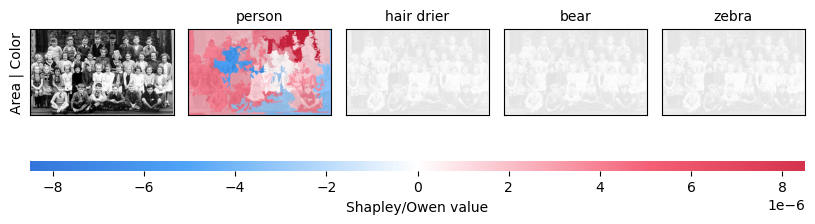

E3_noSAM_2299.png: color scale [-8.5e-06, 8.5e-06]


  0%|          | 0/100 [00:00<?, ?it/s]

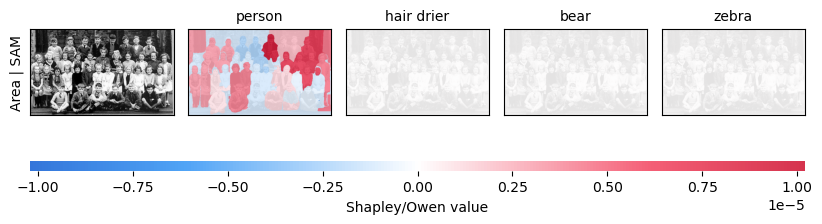

E4_SAM_2299.png: color scale [-1.021e-05, 1.021e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

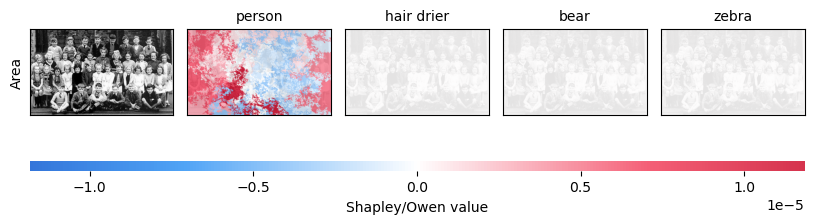

E4_noSAM_2299.png: color scale [-1.184e-05, 1.184e-05]


  0%|          | 0/100 [00:00<?, ?it/s]

Reached 1 terminals.


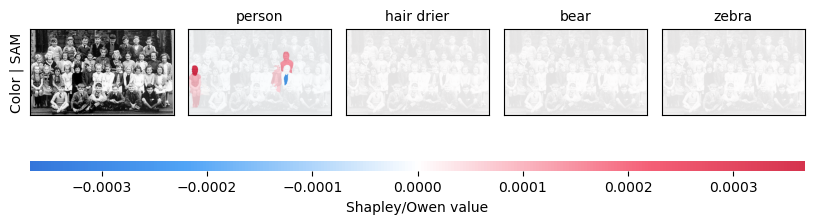

E7_SAM_2299.png: color scale [-0.000206, 0.000206]


  0%|          | 0/100 [00:00<?, ?it/s]

Reached 8 terminals.


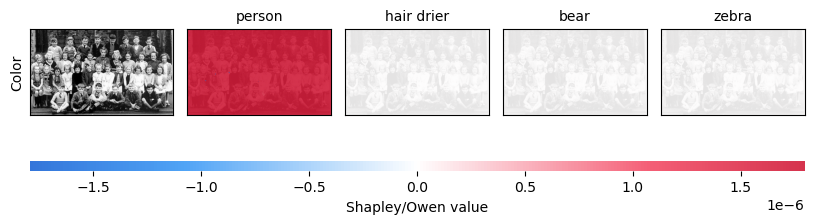

E7_noSAM_2299.png: color scale [-1.796e-06, 1.796e-06]


  0%|          | 0/100 [00:00<?, ?it/s]

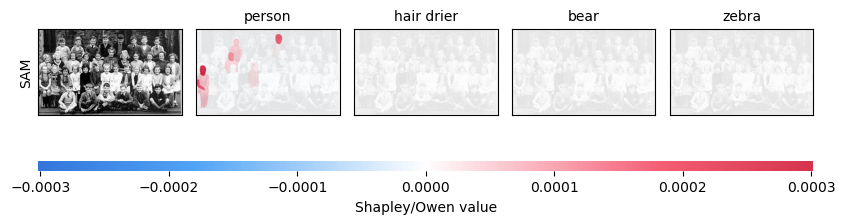

E8_SAM_2299.png: color scale [-0.0002069, 0.0002069]


  0%|          | 0/100 [00:00<?, ?it/s]

Reached 30 terminals.


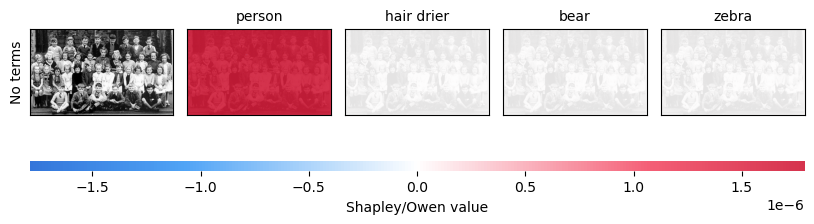

E8_noSAM_2299.png: color scale [-1.79e-06, 1.79e-06]


In [236]:
# Create the shap_bpt explainer using our masking-based black-box function
explainer   = shap_bpt.Explainer(predict_yolo_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)
partitions = cap_partition_labels(masks, max_labels=63)
from tqdm.auto import tqdm
shap_values_all = []
for use_perim_term in [True, False]:
    for use_area_term in [True, False]:
        for use_color_term in [True, False]:
            for use_sam_partitions in [True, False]:
                bptree = shap_bpt.build_bpt_from_image(image_to_explain,
                                                       use_perim_term=use_perim_term,
                                                       use_area_term=use_area_term,
                                                       use_color_term=use_color_term,
                                                       prebuilt_partitions=partitions if use_sam_partitions else None
                                                       )
                # Compute Owen values with the BPT method
                shap_values_bpt_sam = explainer.explain_instance(MAX_EVALS_BUDGET, method='BPT',
                                                            bpt=bptree,
                                                            batch_size=64)
                active_terms = []
                if use_perim_term: active_terms.append('Perimeter')
                if use_area_term: active_terms.append('Area')
                if use_color_term: active_terms.append('Color')
                if use_sam_partitions: active_terms.append('SAM')
                string_names = ' | '.join(active_terms) or 'No terms'

                exp_code = get_experiment_code(use_area_term, use_perim_term, use_color_term)
                figure_name = f'{exp_code}_{"SAM" if use_sam_partitions else "noSAM"}_{image_no}.png'

                plot_owen_values(explainer, shap_values_bpt_sam, class_names,figure_name, names=[string_names], save_plot=False, savepath= path_results_img)
                plot_single_attributions(shap_values_bpt_sam, path_results_img,  figure_name)
                data = {'exp_code':exp_code,
                 'shap_values':shap_values_bpt_sam[0]
                 }
                shap_values_all.append(data)
                # plt.gcf().savefig(os.path.join(path_results, figure_name), dpi=300, bbox_inches='tight')
                # print(f'Saved figure: {figure_name}')
                ## save this plot if needed

## HTML REPORT

In [277]:
import sys

scripts_dir = project_root / "examples/scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from utils import build_html_report, saliency_to_auc

In [278]:
report_path = build_html_report(path_results_img, os.path.join(path_results, f'shapbpt_report_{image_id}.html'),experiment_map, experiment_table, image_id)


HTML report saved to: /Users/rashid/Nextcloud/RashidPHD/Codes/XAI/ShapBPT-SAM/shap_bpt_sam/examples/notebooks/results/shapbpt_report_000000171382.html


## Evaluation

In [279]:
predicted_cls = explainer.output_indexes[0]
f_S = explainer.base_f_S[0]
f_0 = explainer.base_f_0[0]

aucD_bpt = saliency_to_auc(predict_yolo_masked, shap_values_bpt_sam[0], f_S, f_0, predicted_cls, method='del')
aucI_bpt = saliency_to_auc(predict_yolo_masked, shap_values_bpt_sam[0], f_S, f_0, predicted_cls, method='ins')

# shap_values_sam
# shap_values_bpt_sam
# shap_values_aa


In [280]:
def compute_auc_results(shap_values_all, nu, f_S, f_0, predicted_cls, batch_size=4):
    auc_results = []
    label_counts = {}

    for exp_data in shap_values_all:
        exp_code = exp_data['exp_code']
        base_label = exp_data.get('label', exp_code)
        label_counts[base_label] = label_counts.get(base_label, 0) + 1
        label = base_label if label_counts[base_label] == 1 else f"{base_label} #{label_counts[base_label]}"

        shap_values = exp_data['shap_values']
        auc_del = saliency_to_auc(nu, shap_values, f_S, f_0, predicted_cls, batch_size=batch_size, method='del')
        auc_ins = saliency_to_auc(nu, shap_values, f_S, f_0, predicted_cls, batch_size=batch_size, method='ins')

        auc_results.append({
            **exp_data,
            'label': label,
            'auc_del': auc_del,
            'auc_ins': auc_ins,
        })

        print(f"{label}: AUC-DEL={auc_del['auc_clipr']:.4f}, AUC-INS={auc_ins['auc_clipr']:.4f}")

    return auc_results


def plot_auc_results(auc_results, figsize=(11, 4), fill_alpha=0.08):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)
    cmap = plt.get_cmap('tab20')

    best_ins = max(r['auc_ins']['auc_clipr'] for r in auc_results)
    best_del = min(r['auc_del']['auc_clipr'] for r in auc_results)

    panels = [
        (axes[0], 'auc_ins', best_ins, True, '$\\mathit{AUC}^{+}$', 'lower right'),
        (axes[1], 'auc_del', best_del, False, '$\\mathit{AUC}^{-}$', 'upper right'),
    ]

    for ax, auc_key, best_auc, higher_is_better, title, legend_loc in panels:
        sorted_results = sorted(
            auc_results,
            key=lambda result: result[auc_key]['auc_clipr'],
            reverse=higher_is_better,
        )

        for idx, result in enumerate(sorted_results):
            auc = result[auc_key]
            score = auc['auc_clipr']
            is_best = np.isclose(score, best_auc)
            color = cmap(idx % cmap.N)
            star = '*' if is_best else ''

            ax.plot(
                auc['xs'],
                auc['y_clipr'],
                color=color,
                lw=2.4 if is_best else 1.4,
                alpha=0.95 if is_best else 0.75,
                label=f"{star}{result['label']} {score:.4f}",
            )
            ax.fill_between(auc['xs'], auc['y_clipr'], color=color, alpha=fill_alpha)

        ax.axhline(1.0, ls='--', c='grey', zorder=0)
        ax.axhline(0.0, c='lightgrey', zorder=0)
        ax.set_title(title, fontsize=16)
        ax.set_xlabel('Fraction of Pixels Removed/Inserted')
        ax.grid(alpha=0.25)
        ax.legend(borderpad=0.2, labelspacing=0.1, loc=legend_loc, fontsize=8)

    axes[0].set_ylabel('Model Confidence')
    plt.tight_layout()
    plt.savefig(os.path.join(path_results_img, f'auc_results_{image_no}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    return fig, axes


In [281]:
# auc_results = compute_auc_results(shap_values_bpt_sam, predict_yolo_masked, f_S, f_0, predicted_cls, batch_size=4)
# fig, axes = plot_auc_results(auc_results)

AA: AUC-DEL=0.1931, AUC-INS=0.9715
BPT: AUC-DEL=0.0728, AUC-INS=0.9705
SAM: AUC-DEL=0.4805, AUC-INS=0.9897
BPT-SAM: AUC-DEL=0.2539, AUC-INS=0.9903


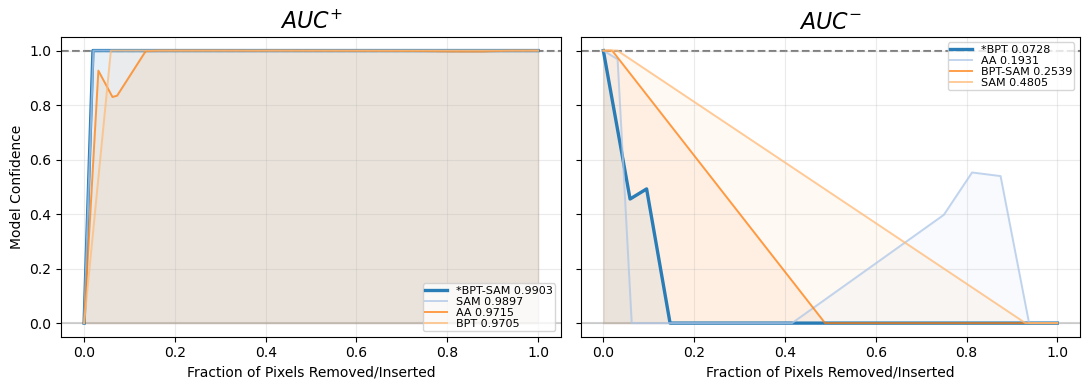

In [282]:
auc_results = compute_auc_results(shap_values_all_4, predict_yolo_masked, f_S, f_0, predicted_cls, batch_size=4)
fig, axes = plot_auc_results(auc_results)

In [ ]:
# predicted_cls = explainer.output_indexes[0]
# f_S = explainer.base_f_S[0]
# f_0 = explainer.base_f_0[0]

# aucI_bpt = saliency_to_auc(predict_yolo_masked, shap_values_bpt[0], f_S, f_0, predicted_cls, method='ins')
# aucD_bpt = saliency_to_auc(predict_yolo_masked, shap_values_bpt[0], f_S, f_0, predicted_cls, method='del')

# aucI_sam = saliency_to_auc(predict_yolo_masked, shap_values_sam[0], f_S, f_0, predicted_cls, method='ins')
# aucD_sam = saliency_to_auc(predict_yolo_masked, shap_values_sam[0], f_S, f_0, predicted_cls, method='del')



## END